In [1]:
!pip install -q -U transformers peft accelerate bitsandbytes>=0.46.1 datasets trl
!pip install -q rouge-score nltk

  Preparing metadata (setup.py) ... done


In [2]:
import os, json, glob, inspect, math, time, re
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

import nltk
nltk.download("punkt", quiet=True)

from datasets import Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainerCallback,
    EarlyStoppingCallback,
)
from peft import LoraConfig, prepare_model_for_kbit_training, PeftModel
from trl import SFTConfig, SFTTrainer
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

In [3]:
from google.colab import files

uploaded = files.upload()

DATA_PATH = list(uploaded.keys())[0]
print("Dataset file:", DATA_PATH)

Saving training_data_with_responses (1).json to training_data_with_responses (1).json
Dataset file: training_data_with_responses (1).json


In [4]:
import os, json, glob, inspect, math, time, re
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

import nltk
nltk.download("punkt", quiet=True)

from datasets import Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainerCallback,
    EarlyStoppingCallback,
)
from peft import LoraConfig, prepare_model_for_kbit_training, PeftModel
from trl import SFTConfig, SFTTrainer
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

In [5]:
MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
# MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"

OUTPUT_DIR = "/content/qwen2.5-assistify-finetuned"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MAX_SEQ_LEN = 512
BATCH_SIZE = 2
GRAD_ACCUM = 4
LEARNING_RATE = 1e-4
MAX_STEPS = 600
WARMUP_STEPS = 25
WEIGHT_DECAY = 0.01
LR_SCHEDULER = "cosine"

LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.10

print("MODEL_ID:", MODEL_ID)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("File exists:", os.path.exists(DATA_PATH))

MODEL_ID: Qwen/Qwen2.5-1.5B-Instruct
OUTPUT_DIR: /content/qwen2.5-assistify-finetuned
File exists: True


In [6]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_ID,
    trust_remote_code=True
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

print("Tokenizer loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Tokenizer loaded.


In [7]:
with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

training_data = raw_data["TRAINING_DATA"]
intent_map = raw_data.get("INTENT_MAP", {})

print("Total examples:", len(training_data))
print("Number of intents:", len(intent_map))

for text, intent, response in training_data[:3]:
    print("-" * 60)
    print("Intent:", intent)
    print("Input:", text)
    print("Response:", response)

Total examples: 54000
Number of intents: 18
------------------------------------------------------------
Intent: memory_check
Input: Do you remember my previous order for urine analyzer?
Response: Yes! We can continue regarding urine analyzer. What do you need?
------------------------------------------------------------
Intent: return
Input: Can you help? How long is the warranty for crutch? now
Response: You can return products within 14 days of delivery. Please share your order number and reason for return.
------------------------------------------------------------
Intent: goodbye
Input: بعد إذنك، سلام يا فرح
Response: مع السلامة! لو احتجت أي مساعدة أنا هنا.


In [8]:
SYSTEM_PROMPT = (
    "You are Assistify AI, a professional medical store assistant. "
    "Help users with orders, product inquiries, prices, delivery, returns, and medical equipment. "
    "Always reply in the same language as the user: Arabic or English. "
    "Do not claim you remember previous orders or customer history unless it is explicitly provided in the chat. "
    "If the user asks about a previous order, ask for the order number or details. "
    "If the user asks about a price and no exact price is provided, ask which product/model or say you will check availability and price. "
    "Be helpful, concise, and professional."
)

def format_instruction(text, intent, response):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {
            "role": "user",
            "content": f"User Intent: {intent}\nUser Message: {text}"
        },
        {"role": "assistant", "content": response},
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )
formatted = [
    {
        "text": format_instruction(item[0], item[1], item[2]),
        "intent": item[1],
    }
    for item in training_data
]

dataset = Dataset.from_list(formatted)
dataset = dataset.shuffle(seed=42)

split = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split["train"]
eval_dataset = split["test"]

print("Train size:", len(train_dataset))
print("Eval size:", len(eval_dataset))
print(train_dataset[0]["text"])

Train size: 43200
Eval size: 10800
<|im_start|>system
You are Assistify AI, a professional medical store assistant. Help users with orders, product inquiries, prices, delivery, returns, and medical equipment. Always reply in the same language as the user: Arabic or English. Do not claim you remember previous orders or customer history unless it is explicitly provided in the chat. If the user asks about a previous order, ask for the order number or details. If the user asks about a price and no exact price is provided, ask which product/model or say you will check availability and price. Be helpful, concise, and professional.<|im_end|>
<|im_start|>user
User Intent: recommendation_reasoning
User Message: Can you help? What makes X-ray machine better than others? now<|im_end|>
<|im_start|>assistant
This product was selected based on quality, customer ratings, and value for money. Want me to compare with another option?<|im_end|>



In [9]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

model.config.use_cache = False

print("Model loaded:", MODEL_ID)
print("Device:", next(model.parameters()).device)

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded: Qwen/Qwen2.5-1.5B-Instruct
Device: cuda:0


In [10]:
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_dropout=LORA_DROPOUT,
    bias="none",
    task_type="CAUSAL_LM"
)

print("LoRA ready.")

LoRA ready.


In [11]:
class LossHistoryCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.eval_losses = []
        self.train_steps = []
        self.eval_steps = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return

        step = state.global_step

        if "loss" in logs:
            self.train_losses.append(logs["loss"])
            self.train_steps.append(step)

        if "eval_loss" in logs:
            self.eval_losses.append(logs["eval_loss"])
            self.eval_steps.append(step)

loss_cb = LossHistoryCallback()

In [14]:
sft_config = SFTConfig(
    output_dir=OUTPUT_DIR,
    dataset_text_field="text",
    max_length=MAX_SEQ_LEN,

    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,

    optim="paged_adamw_32bit",
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_type=LR_SCHEDULER,
    warmup_steps=WARMUP_STEPS,

    max_steps=MAX_STEPS,

    fp16=False,
    bf16=False,

    logging_steps=50,
    save_steps=200,
    save_total_limit=2,

    eval_strategy="steps",
    eval_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    report_to="none",
)

In [15]:
print("bnb compute dtype:", bnb_config.bnb_4bit_compute_dtype)
print("fp16:", sft_config.fp16)
print("bf16:", sft_config.bf16)
print("model dtype:", next(model.parameters()).dtype)

bnb compute dtype: torch.float16
fp16: False
bf16: False
model dtype: torch.float32


In [17]:
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    peft_config=peft_config,
    args=sft_config,
    processing_class=tokenizer,
    callbacks=[
        loss_cb,
        EarlyStoppingCallback(early_stopping_patience=3),
    ],
)

Adding EOS to train dataset:   0%|          | 0/43200 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/43200 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/10800 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/10800 [00:00<?, ? examples/s]

In [18]:
trainer.train()
print("Training complete.")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
100,0.352767,0.265671,0.304295,141327.000000,0.939022
200,0.177095,0.157879,0.191552,282138.000000,0.960432
300,0.137343,0.131632,0.149629,423234.000000,0.965289
400,0.119178,0.119752,0.135782,564773.000000,0.967103
500,0.116424,0.114173,0.135093,705912.000000,0.968047
600,0.110247,0.113872,0.134808,846545.000000,0.968137


Training complete.


In [19]:
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)

print("Model saved to:", OUTPUT_DIR)

Model saved to: /content/qwen2.5-assistify-finetuned


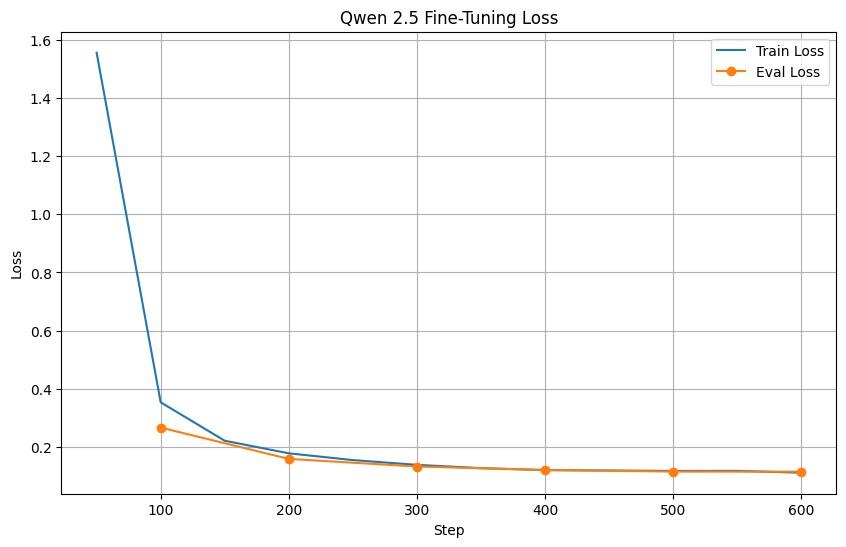

Saved: /content/qwen2.5-assistify-finetuned/loss_curves.png


In [20]:
plt.figure(figsize=(10, 6))

if loss_cb.train_losses:
    plt.plot(loss_cb.train_steps, loss_cb.train_losses, label="Train Loss")

if loss_cb.eval_losses:
    plt.plot(loss_cb.eval_steps, loss_cb.eval_losses, label="Eval Loss", marker="o")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Qwen 2.5 Fine-Tuning Loss")
plt.grid(True)
plt.legend()

loss_path = f"{OUTPUT_DIR}/loss_curves.png"
plt.savefig(loss_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", loss_path)

In [21]:
def chat(text, max_new_tokens=100):
    model.eval()

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": f"User Message: {text}"},
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    t0 = time.time()

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            use_cache=True
        )

    latency = time.time() - t0

    new_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    decoded = tokenizer.decode(new_tokens, skip_special_tokens=True)

    return decoded.strip(), latency

In [22]:
test_cases = [
    "اطلبلي weight scale دلوقتي",
    "Do you remember my previous order for urine analyzer?",
    "Good morning Mariam please",
    "How can I return my blood pressure monitor?",
    "عايز أعرف سعر جهاز الأكسجين",
]

for text in test_cases:
    response, latency = chat(text)
    print("=" * 60)
    print("Input:", text)
    print("Response:", response)
    print(f"Latency: {latency * 1000:.0f} ms")

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Input: اطلبلي weight scale دلوقتي
Response: هجهز طلب weight scale دلوقتي دلوقتي! إيه التفصيلة؟
Latency: 3278 ms
Input: Do you remember my previous order for urine analyzer?
Response: Yes, we can continue regarding urine analyzer! What do you need?
Latency: 2188 ms
Input: Good morning Mariam please
Response: Hi there! Welcome to Assistify. What can I help you with?
Latency: 1936 ms
Input: How can I return my blood pressure monitor?
Response: You can return products within 14 days of delivery. Please share your order number and reason for return.
Latency: 2754 ms
Input: عايز أعرف سعر جهاز الأكسجين
Response: هفحص التوفر دلوقتي. ممكن تديني اسم المنتج بالتحديد؟
Latency: 2615 ms


In [23]:
scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=True
)

sf = SmoothingFunction().method1

r1s, r2s, rLs, bleus, lats = [], [], [], [], []

sample = eval_dataset.select(range(min(40, len(eval_dataset))))

for ex in sample:
    text = ex["text"]

    try:
        user_input = text.split("<|im_start|>user\n")[1].split("<|im_end|>")[0].strip()
        ref_text = text.split("<|im_start|>assistant\n")[1].split("<|im_end|>")[0].strip()
    except:
        continue

    pred_text, lat = chat(user_input)
    lats.append(lat)

    scores = scorer.score(ref_text, pred_text)

    r1s.append(scores["rouge1"].fmeasure)
    r2s.append(scores["rouge2"].fmeasure)
    rLs.append(scores["rougeL"].fmeasure)

    bleu = sentence_bleu(
        [ref_text.split()],
        pred_text.split(),
        smoothing_function=sf
    )
    bleus.append(bleu)

print("ROUGE-1:", round(np.mean(r1s), 4))
print("ROUGE-2:", round(np.mean(r2s), 4))
print("ROUGE-L:", round(np.mean(rLs), 4))
print("BLEU:", round(np.mean(bleus), 4))
print("Avg latency ms:", round(np.mean(lats) * 1000))

ROUGE-1: 0.415
ROUGE-2: 0.3312
ROUGE-L: 0.4082
BLEU: 0.5687
Avg latency ms: 3214


In [25]:
def is_arabic(text):
    return bool(re.search(r"[\u0600-\u06FF]", text))

lang_tests = [
    ("اطلبلي weight scale دلوقتي", True),
    ("How can I return my blood pressure monitor?", False),
    ("عايز أعرف سعر جهاز الأكسجين", True),
    ("What is the price of a pulse oximeter?", False),
    ("ممكن تساعدني في الطلب؟", True),
    ("Do you deliver to Cairo?", False),
]

correct = 0

for text, expect_ar in lang_tests:
    pred, _ = chat(text)
    got_ar = is_arabic(pred)
    ok = got_ar == expect_ar
    correct += int(ok)

    print("=" * 60)
    print("Input:", text)
    print("Response:", pred)
    print("Expected:", "Arabic" if expect_ar else "English")
    print("Got:", "Arabic" if got_ar else "English")
    print("Status:", "OK" if ok else "Wrong")

acc = correct / len(lang_tests) * 100
print(f"Language accuracy: {correct}/{len(lang_tests)} = {acc:.1f}%")

Input: اطلبلي weight scale دلوقتي
Response: هجهز طلب weight scale دلوقتي دلوقتي! إيه التفصيلة؟
Expected: Arabic
Got: Arabic
Status: OK
Input: How can I return my blood pressure monitor?
Response: You can return products within 14 days of delivery. Please share your order number and reason for return.
Expected: English
Got: English
Status: OK
Input: عايز أعرف سعر جهاز الأكسجين
Response: هفحص التوفر دلوقتي. ممكن تديني اسم المنتج بالتحديد؟
Expected: Arabic
Got: Arabic
Status: OK
Input: What is the price of a pulse oximeter?
Response: We have a great selection of pulse oximeters! Tell me your intended use and I'll recommend the best option at the available stock.
Expected: English
Got: English
Status: OK
Input: ممكن تساعدني في الطلب؟
Response: هساعدك مع طلب دلوقتي! إيه اللي تحتاجه بالتحديد؟
Expected: Arabic
Got: Arabic
Status: OK
Input: Do you deliver to Cairo?
Response: Yes, we deliver to Cairo! Want me to add it to your cart at the usual price?
Expected: English
Got: English
Status: OK
L

In [34]:
quality_tests = [

    # Previous Orders / Memory
    {
        "input": "Do you remember my previous order for urine analyzer?",
        "must_contain_any": ["order number", "details", "don't have access", "cannot access"],
        "must_not_contain": ["yes", "remember", "continue regarding"]
    },
    {
        "input": "What was my last order?",
        "must_contain_any": ["order number", "details", "don't have access"],
        "must_not_contain": ["your last order", "i remember"]
    },
    {
        "input": "فاكر طلبي اللي فات؟",
        "must_contain_any": ["رقم الطلب", "التفاصيل", "معنديش"],
        "must_not_contain": ["فاكر", "عارف طلبك"]
    },

    # Prices
    {
        "input": "What is the price of a pulse oximeter?",
        "must_contain_any": ["price", "pulse oximeter", "model", "check"],
        "must_not_contain": ["which product are you asking about"]
    },
    {
        "input": "How much is a blood pressure monitor?",
        "must_contain_any": ["blood pressure", "price", "model", "check"],
        "must_not_contain": ["i don't know"]
    },
    {
        "input": "عايز أعرف سعر جهاز الأكسجين",
        "must_contain_any": ["سعر", "الأكسجين", "الموديل", "التوفر"],
        "must_not_contain": ["مش عارف"]
    },

    # Delivery
    {
        "input": "Do you deliver to Cairo?",
        "must_contain_any": ["deliver", "Cairo", "delivery"],
        "must_not_contain": ["processed shortly"]
    },
    {
        "input": "Can you ship to Alexandria?",
        "must_contain_any": ["Alexandria", "deliver", "ship"],
        "must_not_contain": ["cannot answer"]
    },
    {
        "input": "هل التوصيل متاح في الجيزة؟",
        "must_contain_any": ["الجيزة", "التوصيل"],
        "must_not_contain": ["لا أعرف"]
    },

    # Orders
    {
        "input": "I want to order a weight scale",
        "must_contain_any": ["weight scale", "order", "quantity", "model"],
        "must_not_contain": ["cannot help"]
    },
    {
        "input": "اطلبلي ميزان وزن",
        "must_contain_any": ["ميزان", "الطلب", "الموديل", "الكمية"],
        "must_not_contain": ["لا أستطيع"]
    },

    # Returns
    {
        "input": "How can I return my blood pressure monitor?",
        "must_contain_any": ["return", "order", "reason"],
        "must_not_contain": ["cannot return anything"]
    },
    {
        "input": "عايز أرجع المنتج",
        "must_contain_any": ["الإرجاع", "رقم الطلب", "السبب"],
        "must_not_contain": ["ممنوع"]
    },

    # Availability
    {
        "input": "Is the pulse oximeter available?",
        "must_contain_any": ["available", "stock", "check"],
        "must_not_contain": ["don't know"]
    },
    {
        "input": "هل جهاز قياس السكر متوفر؟",
        "must_contain_any": ["متوفر", "التوفر", "المخزون"],
        "must_not_contain": ["معرفش"]
    },

    # Greetings
    {
        "input": "Good morning",
        "must_contain_any": ["good morning", "help", "assist"],
        "must_not_contain": ["order number"]
    },
    {
        "input": "Hello",
        "must_contain_any": ["hello", "help", "assist"],
        "must_not_contain": ["return policy"]
    },
    {
        "input": "صباح الخير",
        "must_contain_any": ["صباح", "مساعدة"],
        "must_not_contain": ["رقم الطلب"]
    },

    # Product Inquiry
    {
        "input": "Tell me about urine analyzers",
        "must_contain_any": ["urine analyzer", "product"],
        "must_not_contain": ["i remember your order"]
    },
    {
        "input": "عايز معلومات عن جهاز أكسجين",
        "must_contain_any": ["جهاز", "أكسجين"],
        "must_not_contain": ["طلبك السابق"]
    },

    # Support
    {
        "input": "Can you help me place an order?",
        "must_contain_any": ["order", "help"],
        "must_not_contain": ["cannot assist"]
    },
    {
        "input": "ممكن تساعدني في الطلب؟",
        "must_contain_any": ["مساعدة", "الطلب"],
        "must_not_contain": ["لا أستطيع"]
    }
]

passed = 0

for test in quality_tests:
    pred, _ = chat(test["input"])
    pred_l = pred.lower()

    ok_contains = any(x.lower() in pred_l for x in test["must_contain_any"])
    ok_not_contains = all(x.lower() not in pred_l for x in test["must_not_contain"])

    ok = ok_contains and ok_not_contains
    passed += int(ok)

    print("=" * 60)
    print("Input:", test["input"])
    print("Response:", pred)
    print("Status:", "OK" if ok else "Wrong")

print(f"Quality accuracy: {passed}/{len(quality_tests)} = {passed/len(quality_tests)*100:.1f}%")

Input: Do you remember my previous order for urine analyzer?
Response: Yes, we can continue regarding urine analyzer! What do you need?
Status: Wrong
Input: What was my last order?
Response: I'll get you that order! Could you share the order number or details?
Status: OK
Input: فاكر طلبي اللي فات؟
Response: هجهز طلبك دلوقتي! ممكن تديني اسم المنتج بالتحديد أو الموديل عشان أبدأ الطلب؟
Status: Wrong
Input: What is the price of a pulse oximeter?
Response: We have a great selection of pulse oximeters! Tell me your intended use and I'll recommend the best option at the available stock.
Status: OK
Input: How much is a blood pressure monitor?
Response: We have a great selection of blood pressure monitors! Tell me your intended use and I'll recommend the best option at the best price.
Status: OK
Input: عايز أعرف سعر جهاز الأكسجين
Response: هفحص التوفر دلوقتي. ممكن تديني اسم المنتج بالتحديد؟
Status: OK
Input: Do you deliver to Cairo?
Response: Yes, we deliver to Cairo! Want me to add it to your 

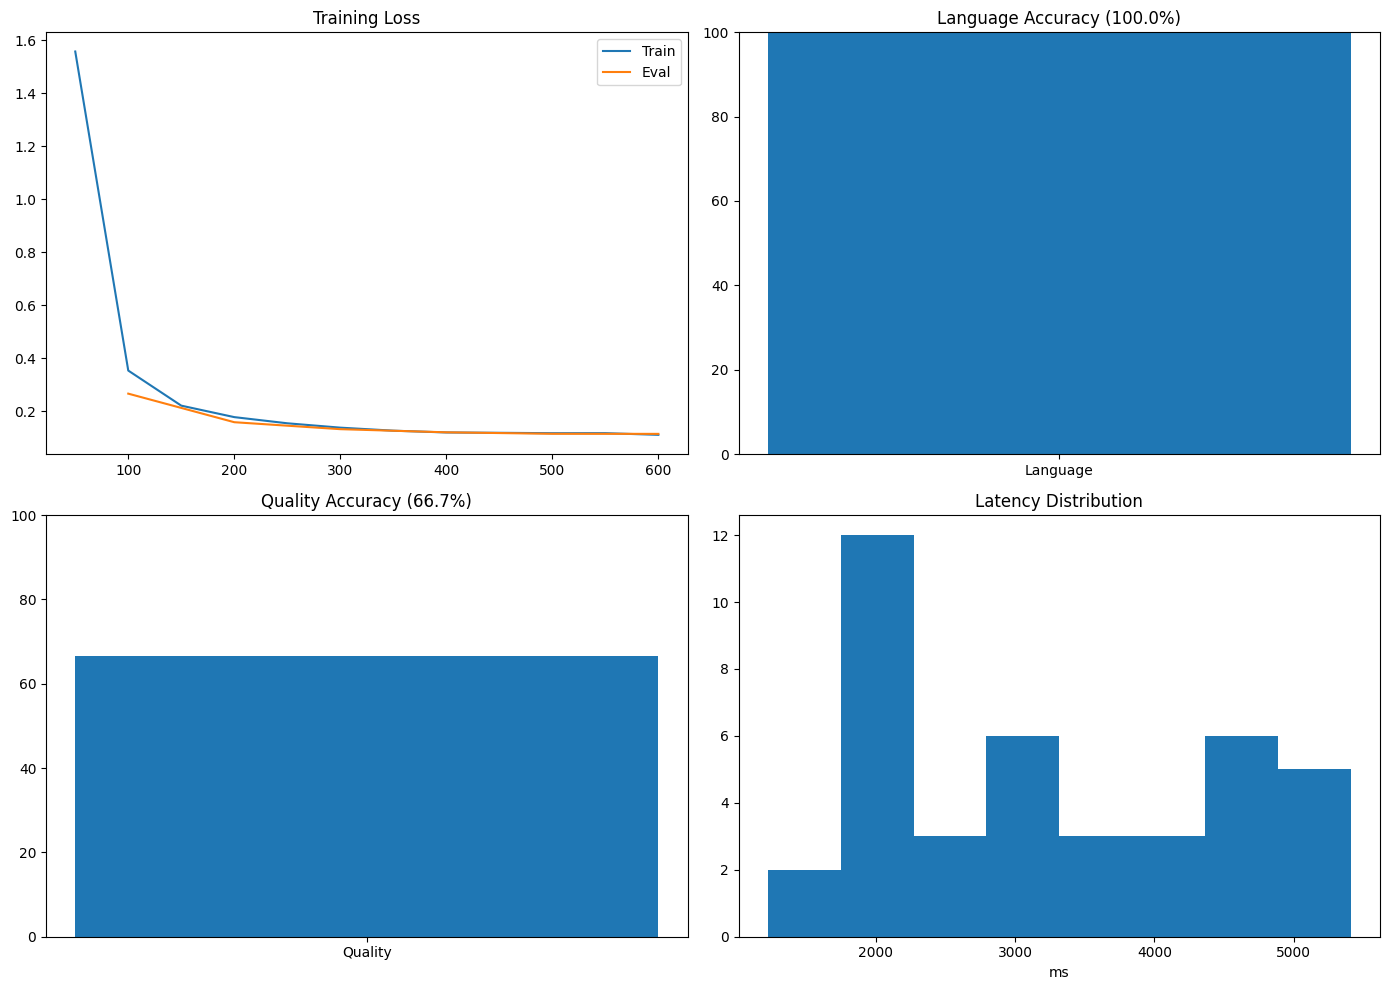

In [29]:
fig = plt.figure(figsize=(14,10))

# Loss
plt.subplot(2,2,1)
plt.plot(loss_cb.train_steps, loss_cb.train_losses,label="Train")
plt.plot(loss_cb.eval_steps, loss_cb.eval_losses,label="Eval")
plt.title("Training Loss")
plt.legend()

# Language
plt.subplot(2,2,2)
plt.bar(["Language"], [acc])
plt.ylim(0,100)
plt.title(f"Language Accuracy ({acc:.1f}%)")

# Quality
quality_acc = passed/len(quality_tests)*100
plt.subplot(2,2,3)
plt.bar(["Quality"], [quality_acc])
plt.ylim(0,100)
plt.title(f"Quality Accuracy ({quality_acc:.1f}%)")

# Latency
plt.subplot(2,2,4)
plt.hist(np.array(lats)*1000,bins=8)
plt.title("Latency Distribution")
plt.xlabel("ms")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dashboard.png", dpi=200)
plt.show()

In [30]:
!zip -r /content/qwen2.5-assistify-finetuned.zip /content/qwen2.5-assistify-finetuned

from google.colab import files
files.download("/content/qwen2.5-assistify-finetuned.zip")

  adding: content/qwen2.5-assistify-finetuned/ (stored 0%)
  adding: content/qwen2.5-assistify-finetuned/dashboard.png (deflated 25%)
  adding: content/qwen2.5-assistify-finetuned/checkpoint-600/ (stored 0%)
  adding: content/qwen2.5-assistify-finetuned/checkpoint-600/README.md (deflated 65%)
  adding: content/qwen2.5-assistify-finetuned/checkpoint-600/optimizer.pt (deflated 8%)
  adding: content/qwen2.5-assistify-finetuned/checkpoint-600/scheduler.pt (deflated 61%)
  adding: content/qwen2.5-assistify-finetuned/checkpoint-600/tokenizer.json (deflated 81%)
  adding: content/qwen2.5-assistify-finetuned/checkpoint-600/chat_template.jinja (deflated 71%)
  adding: content/qwen2.5-assistify-finetuned/checkpoint-600/training_args.bin (deflated 53%)
  adding: content/qwen2.5-assistify-finetuned/checkpoint-600/adapter_model.safetensors (deflated 21%)
  adding: content/qwen2.5-assistify-finetuned/checkpoint-600/trainer_state.json (deflated 74%)
  adding: content/qwen2.5-assistify-finetuned/check

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>